<a href="https://colab.research.google.com/github/mnguyen175/DRSP-2026-Maryan-Nguyen-/blob/main/DRSP_Final_Project_2026_Maryan_Nguyen.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import pandas as pd # import pandas

!pip install matplotlib # import matplotlib
import matplotlib.pyplot as plt

In [6]:
df = pd.read_csv("/content/nyt_bestsellers_combined.csv")
df.head(5)

,year,week,rank,title_id,title,author,pub_year,total_weeks,first_week,debut_rank,best_rank
0,1931,1931-10-12,1,6477,THE TEN COMMANDMENTS,Warwick Deeping,1931,1,1931-10-12,1,1
1,1931,1931-10-12,2,1808,FINCHE'S FORTUNE,Mazo de la Roche,1931,1,1931-10-12,2,2
2,1931,1931-10-12,3,5304,THE GOOD EARTH,Pearl S. Buck,1931,10,1931-10-12,3,1
3,1931,1931-10-12,4,4038,SHADOWS ON THE ROCK,Willa Cather,1931,1,1931-10-12,4,4
4,1931,1931-10-12,5,3946,SCARMOUCHE THE KING MAKER,Rafael Sabatini,1931,1,1931-10-12,5,5


In [7]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [8]:
df.shape # 60386 rows (instances), 11 columns (variables)

(60386, 11)

In [9]:
df.info() # author has null objects, there are only objects and ints in the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60386 entries, 0 to 60385
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   year         60386 non-null  int64 
 1   week         60386 non-null  object
 2   rank         60386 non-null  int64 
 3   title_id     60386 non-null  int64 
 4   title        60386 non-null  object
 5   author       60376 non-null  object
 6   pub_year     60386 non-null  int64 
 7   total_weeks  60386 non-null  int64 
 8   first_week   60386 non-null  object
 9   debut_rank   60386 non-null  int64 
 10  best_rank    60386 non-null  int64 
dtypes: int64(7), object(4)
memory usage: 5.1+ MB


In [17]:
df.describe()

,year,rank,title_id,pub_year,total_weeks,debut_rank,best_rank
count,60376.000000,60376.000000,60376.000000,60376.000000,60376.000000,60376.000000,60376.000000
mean,1980.298910,7.578657,3810.370429,1980.030161,23.586524,7.897807,4.075179
std,24.435367,4.401698,2118.599264,24.471965,25.942469,4.593836,3.457501
min,1931.000000,1.000000,0.000000,1931.000000,1.000000,1.000000,1.000000
25%,1958.000000,4.000000,2012.000000,1958.000000,8.000000,4.000000,1.000000
50%,1982.000000,7.000000,3932.000000,1982.000000,16.000000,8.000000,3.000000
75%,2001.000000,11.000000,5599.000000,2001.000000,29.000000,12.000000,6.000000
max,2020.000000,18.000000,7430.000000,2020.000000,178.000000,17.000000,17.000000


In [21]:
print(df['week'].head())
print(df['first_week'].head())

0    1931-10-12
1    1931-10-12
2    1931-10-12
3    1931-10-12
4    1931-10-12
Name: week, dtype: object
0    1931-10-12
1    1931-10-12
2    1931-10-12
3    1931-10-12
4    1931-10-12
Name: first_week, dtype: object


In [15]:
df.isna().sum() # confirm that author has 10 null values

,0
year,0
week,0
rank,0
title_id,0
title,0
author,0
pub_year,0
total_weeks,0
first_week,0
debut_rank,0


In [13]:
df.duplicated().sum()

np.int64(0)

In [14]:
df = df.dropna(subset=['author'])

Text(0.5, 0, 'Times Appeared')

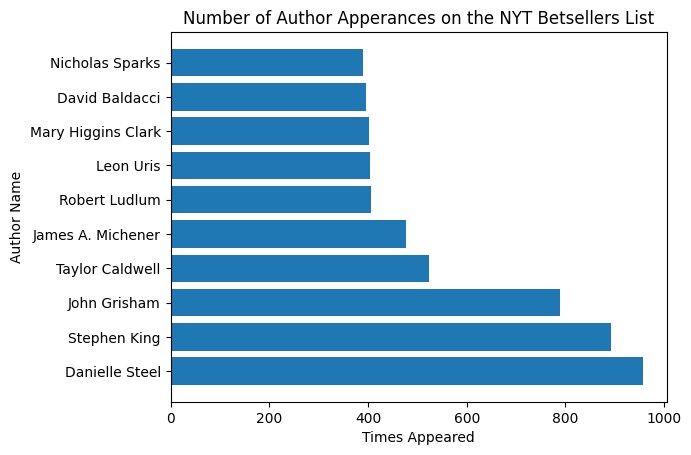

In [28]:
author_counts = df['author'].value_counts().head(10)

# plot the top 10 authors who have the most apperances on the nyt bestsellers list
plt.barh(author_counts.index, author_counts.values)
plt.title("Number of Author Apperances on the NYT Betsellers List")
plt.ylabel("Author Name")
plt.xlabel("Times Appeared")

<BarContainer object of 10 artists>

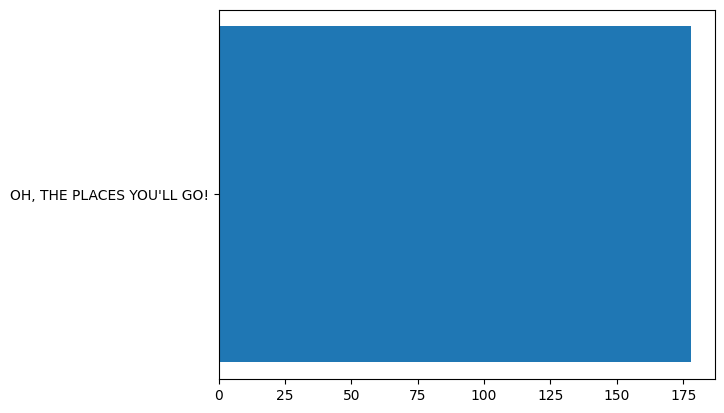

In [35]:
top_books = df[['title','total_weeks']].sort_values(
    by='total_weeks', ascending=False).head(10)

plt.barh(top_books['title'], top_books['total_weeks'])